In [59]:
from google.colab import drive
drive.mount('/content/drive') # Allows access to the dataset stored in Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import numpy for numerical computations
import numpy as np
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt
# Import seaborn for attractive statistical visualizations
import seaborn as sns
# Import LabelEncoder for converting text labels into numbers
from sklearn.preprocessing import LabelEncoder
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Import train_test_split for splitting dataset
from sklearn.model_selection import train_test_split
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# Import K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier
# Import Support Vector Machine
from sklearn.svm import SVC
# Import Accuracy Score
from sklearn.metrics import accuracy_score
# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# Import joblib library for saving and loading machine learning models
import joblib
# Import warnings module to suppress unnecessary warning messages
import warnings
# Ignore all warning messages
warnings.filterwarnings('ignore')
# Display plots inside the Jupyter Notebook
%matplotlib inline

In [61]:
# Read the CSV dataset from the current folder
df = pd.read_csv("/content/drive/MyDrive/Resume Agent/resumes.csv")
# Display the first five rows of the dataset
df.head()

,Candidate_ID,Candidate_Name,Email,Phone,City,Degree,University,Graduation_Year,CGPA,Experience_Years,Skills,Certifications,Projects,Internships,ATS_Score,Current_Role,Applied_Role,Expected_Salary,Notice_Period,Selected
0,1001,Arjun Sharma,arjun.sharma1@gmail.com,9433218196,Bangalore,B.Tech CSE,VTU,2021,6.91,0,Linux; Flask; Scikit-learn; PyTorch; Power BI;...,3,5,0,93,Machine Learning Engineer,Software Engineer,900000,30,0
1,1002,Sai Reddy,sai.reddy2@gmail.com,9511615594,Bangalore,M.Sc Statistics,NIT Trichy,2019,9.80,6,PyTorch; Spring Boot; Scikit-learn; Flask; Django,2,4,0,47,Backend Developer,Frontend Developer,500000,15,0
2,1003,Arjun Iyer,arjun.iyer3@gmail.com,9475255341,Coimbatore,MCA,NIT Trichy,2021,6.64,6,Flask; Linux; PyTorch; Kubernetes; Git; React;...,1,1,2,70,Frontend Developer,AI Engineer,700000,60,0
3,1004,Sneha Reddy,sneha.reddy4@gmail.com,9767242388,Pune,B.Com,IIT Madras,2024,7.41,2,Machine Learning; NLP; SQL; Deep Learning; AWS...,4,2,3,69,QA Engineer,DevOps Engineer,800000,60,0
4,1005,Aarav Rao,aarav.rao5@gmail.com,9184514627,Bangalore,BCA,NIT Trichy,2020,7.98,1,Scikit-learn; Flask; TensorFlow; Django; Docke...,1,1,2,76,Data Analyst,AI Engineer,900000,30,0


In [62]:
# Print the number of rows and columns
print("Dataset Shape:", df.shape)
# Display detailed information about the dataset
df.info()

Dataset Shape: (11000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Candidate_ID      11000 non-null  int64  
 1   Candidate_Name    11000 non-null  object 
 2   Email             11000 non-null  object 
 3   Phone             11000 non-null  int64  
 4   City              11000 non-null  object 
 5   Degree            11000 non-null  object 
 6   University        11000 non-null  object 
 7   Graduation_Year   11000 non-null  int64  
 8   CGPA              11000 non-null  float64
 9   Experience_Years  11000 non-null  int64  
 10  Skills            11000 non-null  object 
 11  Certifications    11000 non-null  int64  
 12  Projects          11000 non-null  int64  
 13  Internships       11000 non-null  int64  
 14  ATS_Score         11000 non-null  int64  
 15  Current_Role      11000 non-null  object 
 16  Applied_Role 

In [63]:
# Display the number of missing values in each column
df.isnull().sum()

,0
Candidate_ID,0
Candidate_Name,0
Email,0
Phone,0
City,0
Degree,0
University,0
Graduation_Year,0
CGPA,0
Experience_Years,0


In [64]:
# Display summary statistics for numerical columns
df.describe()

,Candidate_ID,Phone,Graduation_Year,CGPA,Experience_Years,Certifications,Projects,Internships,ATS_Score,Expected_Salary,Notice_Period,Selected
count,11000.000000,1.100000e+04,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,11000.000000,11000.000000
mean,6500.500000,9.503314e+09,2021.979000,7.950010,3.988909,2.510182,4.520636,1.510455,71.922364,7.600273e+05,39.681818,0.217182
std,3175.570815,2.871788e+08,2.603196,1.117341,2.573453,1.719879,2.288520,1.120716,15.887359,2.507075e+05,29.461692,0.412346
min,1001.000000,9.000018e+09,2018.000000,6.000000,0.000000,0.000000,1.000000,0.000000,45.000000,4.000000e+05,0.000000,0.000000
25%,3750.750000,9.256156e+09,2020.000000,6.990000,2.000000,1.000000,3.000000,1.000000,58.000000,5.000000e+05,15.000000,0.000000
50%,6500.500000,9.502776e+09,2022.000000,7.940000,4.000000,3.000000,5.000000,2.000000,72.000000,7.000000e+05,30.000000,0.000000
75%,9250.250000,9.750960e+09,2024.000000,8.920000,6.000000,4.000000,7.000000,3.000000,86.000000,9.000000e+05,60.000000,0.000000
max,12000.000000,9.999973e+09,2026.000000,9.900000,8.000000,5.000000,8.000000,3.000000,99.000000,1.200000e+06,90.000000,1.000000


In [65]:
# Display 10 random records from the dataset
df.sample(10)

,Candidate_ID,Candidate_Name,Email,Phone,City,Degree,University,Graduation_Year,CGPA,Experience_Years,Skills,Certifications,Projects,Internships,ATS_Score,Current_Role,Applied_Role,Expected_Salary,Notice_Period,Selected
2740,3741,Neha Yadav,neha.yadav2741@gmail.com,9140081452,Jaipur,B.Com,Anna University,2024,8.09,2,Excel; OpenCV; Spring Boot; Java; Python,3,5,2,56,Machine Learning Engineer,Frontend Developer,800000,90,0
847,1848,Sai Reddy,sai.reddy848@gmail.com,9272371798,Coimbatore,B.Tech CSE,JNTU Hyderabad,2020,6.89,0,Linux; Scikit-learn; spaCy; NLP; Power BI,2,5,3,48,Data Scientist,Frontend Developer,1200000,45,0
7281,8282,Aarav Sharma,aarav.sharma7282@gmail.com,9888291510,Hyderabad,B.Tech IT,Mumbai University,2025,7.61,0,MongoDB; Node.js; Flask; Excel; AWS; Python; T...,5,6,2,45,Software Engineer,Data Scientist,1000000,30,0
8452,9453,Priya Singh,priya.singh8453@gmail.com,9267144593,Pune,MCA,VTU,2026,7.74,2,TensorFlow; spaCy; Kubernetes; Django; Power B...,5,1,3,78,AI Engineer,Data Scientist,1000000,60,1
1698,2699,Aisha Iyer,aisha.iyer1699@gmail.com,9089601066,Delhi,M.Sc Statistics,NIT Trichy,2020,8.75,2,Power BI; Node.js; PyTorch; AWS; FastAPI; Dock...,2,5,0,85,Frontend Developer,Frontend Developer,900000,0,1
7389,8390,Vikram Reddy,vikram.reddy7390@gmail.com,9189422225,Jaipur,M.Tech AI,VTU,2025,7.43,6,Git; Deep Learning; Tableau; Excel; OpenCV; Fl...,1,6,3,61,Full Stack Developer,Frontend Developer,1000000,45,0
3749,4750,Priya Reddy,priya.reddy3750@gmail.com,9468456860,Bangalore,BCA,JNTU Hyderabad,2025,7.01,8,Machine Learning; Kubernetes; Flask; spaCy; Ta...,5,1,2,95,Data Analyst,Frontend Developer,900000,0,1
10427,11428,Meera Yadav,meera.yadav10428@gmail.com,9173715435,Mumbai,B.Tech CSE,Anna University,2024,6.59,6,Tableau; Kubernetes; Machine Learning; Spring ...,4,5,0,93,Frontend Developer,Backend Developer,1200000,30,0
10681,11682,Aditya Gupta,aditya.gupta10682@gmail.com,9768717475,Delhi,BCA,Anna University,2020,9.37,3,OpenCV; spaCy; Azure; React; Tableau,5,5,0,61,QA Engineer,Full Stack Developer,700000,0,0
4189,5190,Aisha Singh,aisha.singh4190@gmail.com,9699193031,Delhi,BCA,JNTU Hyderabad,2023,7.61,4,NLP; Django; Kubernetes; PyTorch; Scikit-learn...,0,6,1,62,DevOps Engineer,Data Analyst,500000,30,0


In [66]:
# Print all column names
print(df.columns)

Index(['Candidate_ID', 'Candidate_Name', 'Email', 'Phone', 'City', 'Degree',
       'University', 'Graduation_Year', 'CGPA', 'Experience_Years', 'Skills',
       'Certifications', 'Projects', 'Internships', 'ATS_Score',
       'Current_Role', 'Applied_Role', 'Expected_Salary', 'Notice_Period',
       'Selected'],
      dtype='object')


In [67]:
# Count how many candidates are selected and not selected
df['Selected'].value_counts()

,count
Selected,
0,8611
1,2389


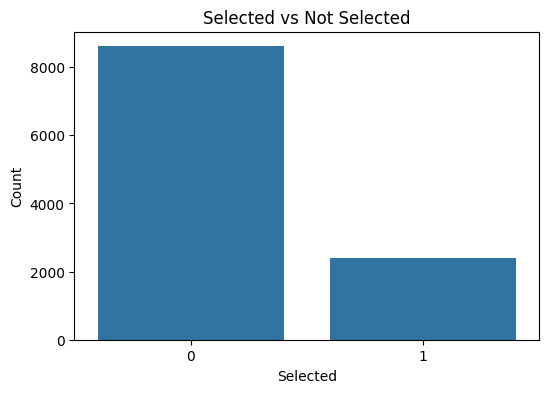

In [68]:
# Set the figure size
plt.figure(figsize=(6,4))
# Create a count plot for the target variable
sns.countplot(x='Selected', data=df)
# Add plot title
plt.title("Selected vs Not Selected")
# Label x-axis
plt.xlabel("Selected")
# Label y-axis
plt.ylabel("Count")
# Display the graph
plt.show()

In [69]:
# Display the data type of each column
df.dtypes

,0
Candidate_ID,int64
Candidate_Name,object
Email,object
Phone,int64
City,object
Degree,object
University,object
Graduation_Year,int64
CGPA,float64
Experience_Years,int64


In [70]:
print(df['Degree'].unique())
# Display unique current job roles
print(df['Current_Role'].unique())
# Display unique applied job roles
print(df['Applied_Role'].unique())

['B.Tech CSE' 'M.Sc Statistics' 'MCA' 'B.Com' 'BCA' 'B.Tech IT'
 'M.Tech AI' 'MBA']
['Machine Learning Engineer' 'Backend Developer' 'Frontend Developer'
 'QA Engineer' 'Data Analyst' 'DevOps Engineer' 'Software Engineer'
 'AI Engineer' 'Data Scientist' 'Full Stack Developer']
['Software Engineer' 'Frontend Developer' 'AI Engineer' 'DevOps Engineer'
 'Backend Developer' 'Machine Learning Engineer' 'Data Analyst'
 'Data Scientist' 'Full Stack Developer' 'QA Engineer']


In [71]:
# Create LabelEncoder object for Education
education_encoder = LabelEncoder()
# Create LabelEncoder object for Current Role
current_role_encoder = LabelEncoder()
# Create LabelEncoder object for Applied Role
applied_role_encoder = LabelEncoder()

In [72]:
# Convert education text into numerical values
df['Degree'] = education_encoder.fit_transform(df['Degree'])
# Convert current role text into numbers
df['Current_Role'] = current_role_encoder.fit_transform(df['Current_Role'])
# Convert applied role text into numbers
df['Applied_Role'] = applied_role_encoder.fit_transform(df['Applied_Role'])

In [73]:
# Create TF-IDF object
tfidf = TfidfVectorizer()
# Convert skills text into TF-IDF feature vectors
skills_features = tfidf.fit_transform(df['Skills'])
# Convert TF-IDF matrix into a DataFrame
skills_df = pd.DataFrame(
    skills_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

In [74]:
# Remove the original text-based Skills column
df = df.drop('Skills', axis=1)

In [75]:
# Combine numerical features with TF-IDF skill features
df = pd.concat([df, skills_df], axis=1)

In [76]:
# Display the first five rows of the transformed dataset
df.head()

,Candidate_ID,Candidate_Name,Email,Phone,City,Degree,University,Graduation_Year,CGPA,Experience_Years,...,power,python,pytorch,react,scikit,spacy,spring,sql,tableau,tensorflow
0,1001,Arjun Sharma,arjun.sharma1@gmail.com,9433218196,Bangalore,1,VTU,2021,6.91,0,...,0.350837,0.0,0.357407,0.000000,0.352629,0.0,0.000000,0.000000,0.0,0.000000
1,1002,Sai Reddy,sai.reddy2@gmail.com,9511615594,Bangalore,4,NIT Trichy,2019,9.80,6,...,0.000000,0.0,0.382146,0.000000,0.377037,0.0,0.378093,0.000000,0.0,0.000000
2,1003,Arjun Iyer,arjun.iyer3@gmail.com,9475255341,Coimbatore,7,NIT Trichy,2021,6.64,6,...,0.000000,0.0,0.380366,0.378514,0.000000,0.0,0.000000,0.380547,0.0,0.000000
3,1004,Sneha Reddy,sneha.reddy4@gmail.com,9767242388,Pune,0,IIT Madras,2024,7.41,2,...,0.295315,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.300988,0.0,0.000000
4,1005,Aarav Rao,aarav.rao5@gmail.com,9184514627,Bangalore,3,NIT Trichy,2020,7.98,1,...,0.000000,0.0,0.000000,0.000000,0.333078,0.0,0.000000,0.000000,0.0,0.332152


In [77]:
# Create feature matrix by removing Candidate_ID and Selected
X = df.drop(['Candidate_ID', 'Selected'], axis=1)
# Create target variable
y = df['Selected']

In [78]:
# Display the shape of the feature matrix
print("Feature Matrix Shape:", X.shape)
# Display the shape of the target variable
print("Target Shape:", y.shape)

Feature Matrix Shape: (11000, 49)
Target Shape: (11000,)


In [79]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [80]:
# Create StandardScaler object
scaler = StandardScaler()

# Identify non-numeric columns that should not be scaled
non_numeric_cols = ['Candidate_Name', 'Email', 'City', 'University']

# Drop non-numeric columns from X_train and X_test before scaling
X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

# Fit scaler on training data and transform it
X_train = scaler.fit_transform(X_train)
# Transform testing data using same scaler
X_test = scaler.transform(X_test)

In [81]:
# Create Logistic Regression model
lr = LogisticRegression(random_state=42)
# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)
# Create SVM model
svm = SVC(probability=True, random_state=42)

In [82]:
# Train Logistic Regression
lr.fit(X_train, y_train)
# Train Decision Tree
dt.fit(X_train, y_train)
# Train Random Forest
rf.fit(X_train, y_train)
# Train KNN
knn.fit(X_train, y_train)
# Train SVM
svm.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [83]:
# Logistic Regression prediction
lr_pred = lr.predict(X_test)
# Decision Tree prediction
dt_pred = dt.predict(X_test)
# Random Forest prediction
rf_pred = rf.predict(X_test)
# KNN prediction
knn_pred = knn.predict(X_test)
# SVM prediction
svm_pred = svm.predict(X_test)

In [84]:
# Logistic Regression Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
# Decision Tree Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
# Random Forest Accuracy
rf_acc = accuracy_score(y_test, rf_pred)
# KNN Accuracy
knn_acc = accuracy_score(y_test, knn_pred)
# SVM Accuracy
svm_acc = accuracy_score(y_test, svm_pred)

In [85]:
# Print all model accuracies
print("Logistic Regression :", round(lr_acc*100,2),"%")
print("Decision Tree :", round(dt_acc*100,2),"%")
print("Random Forest :", round(rf_acc*100,2),"%")
print("KNN :", round(knn_acc*100,2),"%")
print("SVM :", round(svm_acc*100,2),"%")

Logistic Regression : 85.73 %
Decision Tree : 100.0 %
Random Forest : 100.0 %
KNN : 78.36 %
SVM : 88.59 %


In [86]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc,
        knn_acc,
        svm_acc
    ]
})
# Convert into percentage
comparison["Accuracy"] = comparison["Accuracy"]*100
# Sort from highest accuracy to lowest
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)
# Display comparison table
comparison

,Model,Accuracy
1,Decision Tree,100.000000
2,Random Forest,100.000000
4,SVM,88.590909
0,Logistic Regression,85.727273
3,KNN,78.363636


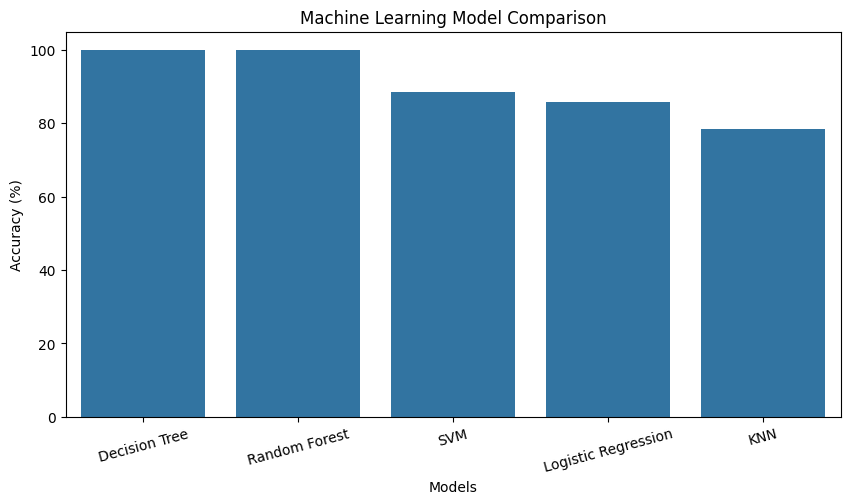

In [87]:
# Set figure size
plt.figure(figsize=(10,5))
# Draw bar plot
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)
# Rotate model names
plt.xticks(rotation=15)
# Graph title
plt.title("Machine Learning Model Comparison")
# X-axis label
plt.xlabel("Models")
# Y-axis label
plt.ylabel("Accuracy (%)")
# Display graph
plt.show()

In [88]:
# Find best model
best_model = comparison.iloc[0]
print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],2),"%")

Best Model : Decision Tree
Accuracy : 100.0 %


In [89]:
# Save Random Forest model
joblib.dump(rf,"model.pkl")
print("Decision Tree saved successfully!")

Decision Tree saved successfully!


In [90]:
# Predict on test dataset
y_pred = rf.predict(X_test)

In [91]:
# Calculate prediction accuracy
accuracy = accuracy_score(y_test, y_pred)
# Print accuracy
print("Accuracy :", accuracy)

Accuracy : 1.0


In [92]:
# Display Precision, Recall, F1-Score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1706
           1       1.00      1.00      1.00       494

    accuracy                           1.00      2200
   macro avg       1.00      1.00      1.00      2200
weighted avg       1.00      1.00      1.00      2200



In [93]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print confusion matrix
print(cm)

[[1706    0]
 [   0  494]]


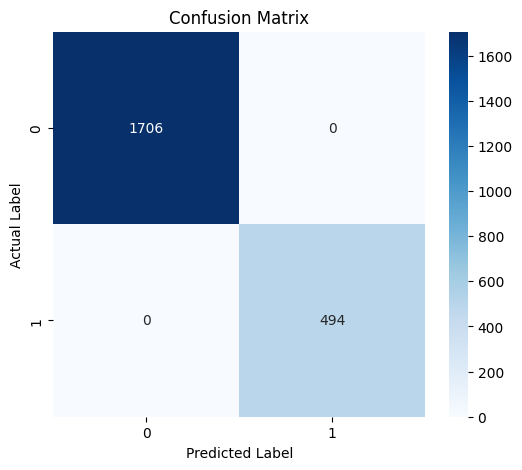

In [94]:
# Set figure size
plt.figure(figsize=(6,5))
# Draw heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
# Set graph title
plt.title("Confusion Matrix")
# X-axis label
plt.xlabel("Predicted Label")
# Y-axis label
plt.ylabel("Actual Label")
# Display graph
plt.show()

In [95]:
import pandas as pd
# Get feature importance scores
importance = rf.feature_importances_
# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns.drop(non_numeric_cols),
    'Importance': importance
})
# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
# Display top 10 important features
feature_importance.head(10)

,Feature,Importance
8,ATS_Score,0.419774
3,CGPA,0.169700
4,Experience_Years,0.144609
5,Certifications,0.106891
0,Phone,0.009618
9,Current_Role,0.005642
10,Applied_Role,0.005014
2,Graduation_Year,0.004885
11,Expected_Salary,0.004664
28,learning,0.004546


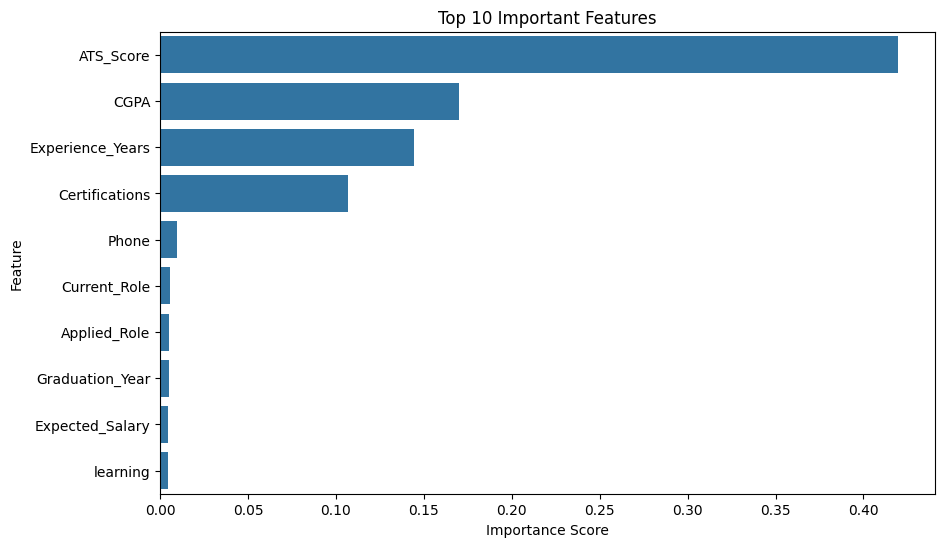

In [96]:
# Set figure size
plt.figure(figsize=(10,6))
# Create bar plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
# Graph title
plt.title("Top 10 Important Features")
# X-axis label
plt.xlabel("Importance Score")
# Y-axis label
plt.ylabel("Feature")
# Display graph
plt.show()

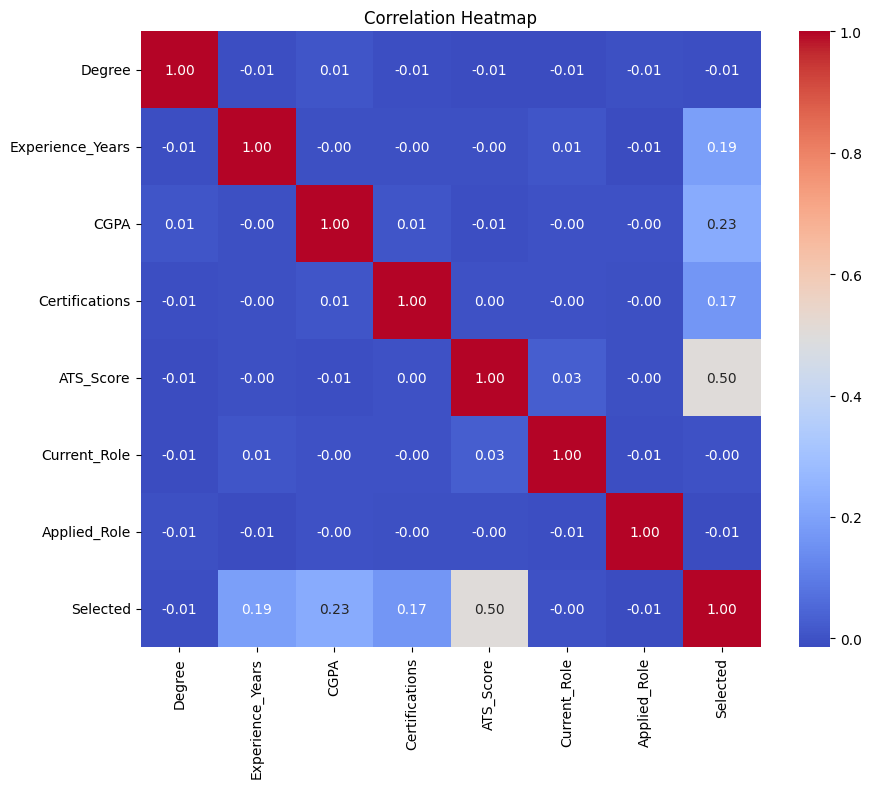

In [97]:
# Select only important numerical columns
numeric_data = df[
    [
        'Degree',
        'Experience_Years',
        'CGPA',
        'Certifications',
        'ATS_Score',
        'Current_Role',
        'Applied_Role',
        'Selected'
    ]
]
# Calculate correlation matrix
corr = numeric_data.corr()
# Set figure size
plt.figure(figsize=(10,8))
# Plot correlation heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
# Add title
plt.title("Correlation Heatmap")
# Display graph
plt.show()

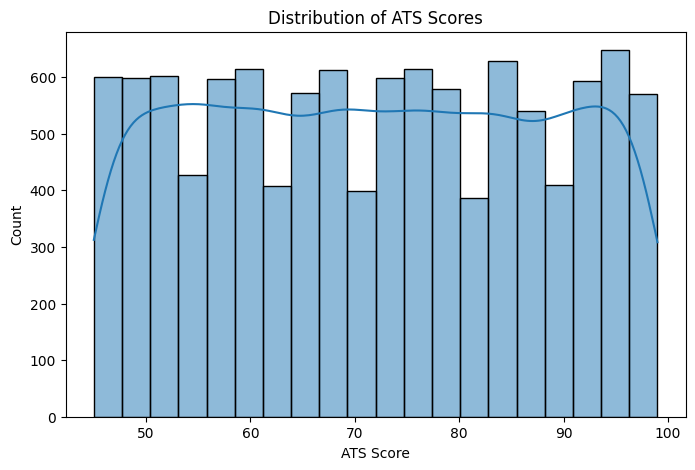

In [98]:
# Set figure size
plt.figure(figsize=(8,5))
# Plot histogram
sns.histplot(
    df['ATS_Score'],
    bins=20,
    kde=True
)
# Graph title
plt.title("Distribution of ATS Scores")
# X-axis label
plt.xlabel("ATS Score")
# Y-axis label
plt.ylabel("Count")
# Display graph
plt.show()

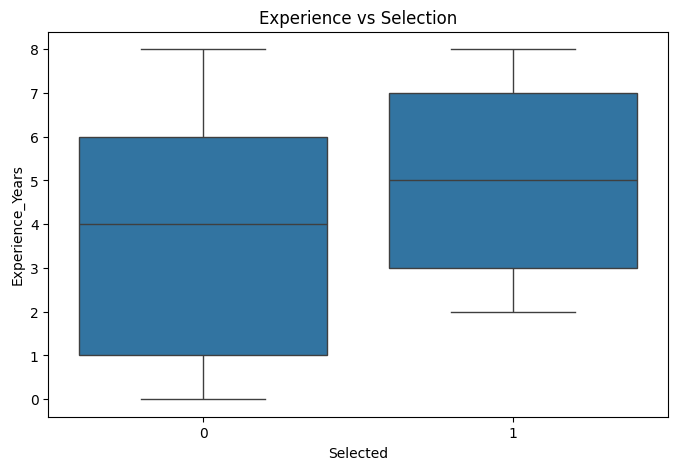

In [99]:
# Set figure size
plt.figure(figsize=(8,5))
# Box plot
sns.boxplot(
    x='Selected',
    y='Experience_Years',
    data=df
)
# Graph title
plt.title("Experience vs Selection")
# Display graph
plt.show()

In [100]:
# Save the trained Random Forest model as model.pkl
joblib.dump(rf, "model.pkl")
# Display success message
print("Model saved successfully!")

Model saved successfully!


In [101]:
# Save the StandardScaler object as scaler.pkl
joblib.dump(scaler, "scaler.pkl")
# Display success message
print("Scaler saved successfully!")

Scaler saved successfully!


In [102]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [103]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [104]:
# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf.pkl")
# Display success message
print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [105]:
# Load the saved machine learning model
loaded_model = joblib.load("model.pkl")
# Load the saved scaler
loaded_scaler = joblib.load("scaler.pkl")
# Load the saved TF-IDF vectorizer
loaded_tfidf = joblib.load("tfidf.pkl")
# Display confirmation
print("All files loaded successfully!")

All files loaded successfully!


In [106]:
# Create a sample candidate as a dictionary
sample_candidate = {
    "Skills": "Python SQL Machine Learning AWS",
    "Education": "B.Tech CSE",
    "Experience_Years": 3,
    "CGPA": 8.4,
    "Certifications": 2,
    "ATS_Score": 85,
    "Current_Role": "Data Analyst",
    "Applied_Role": "Data Analyst"
}

In [107]:
# List all files in the current working directory
import os
# Print all files
print(os.listdir())

['.config', 'tfidf.pkl', 'model.pkl', 'current_role_encoder.pkl', 'education_encoder.pkl', '.ipynb_checkpoints', 'scaler.pkl', 'drive', 'applied_role_encoder.pkl', 'sample_data']


In [108]:
# Save Education LabelEncoder
joblib.dump(education_encoder, "education_encoder.pkl")
# Save Current Role LabelEncoder
joblib.dump(current_role_encoder, "current_role_encoder.pkl")
# Save Applied Role LabelEncoder
joblib.dump(applied_role_encoder, "applied_role_encoder.pkl")
# Display confirmation
print("All encoders saved successfully!")

All encoders saved successfully!
